In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp/Project.toml`
  [13f3f980] CairoMakie v0.15.10
  [033835bb] JLD2 v0.6.4
  [eff96d63] Measurements v2.14.1
  [295af30f] Revise v3.14.3
  [a601b020] WignerMolecule v1.0.0-DEV `..`
  [37e2e46d] LinearAlgebra v1.12.0


In [ ]:
include("Expectation.jl")
using .Expectations
using CairoMakie
using JLD2
using LinearAlgebra
using Measurements

In [11]:
function Measurements.measurement(e::Expectation)
    return e.val ± e.err
end

"""
    getexpansion(name, ord)

Read high-T expansion coefficients for energy from JLD2 file to order ord,
returns closure accepting T
"""
function getexpansion(name, ord)
    all_data = load("expectations.jld2")
    energies = [measurement(all_data["$name/H$i"]) for i in 1:ord]
    return T -> sum([(1/T)^(i-1) for i in 1:ord] .* energies)
end

getexpansion

## Stripe

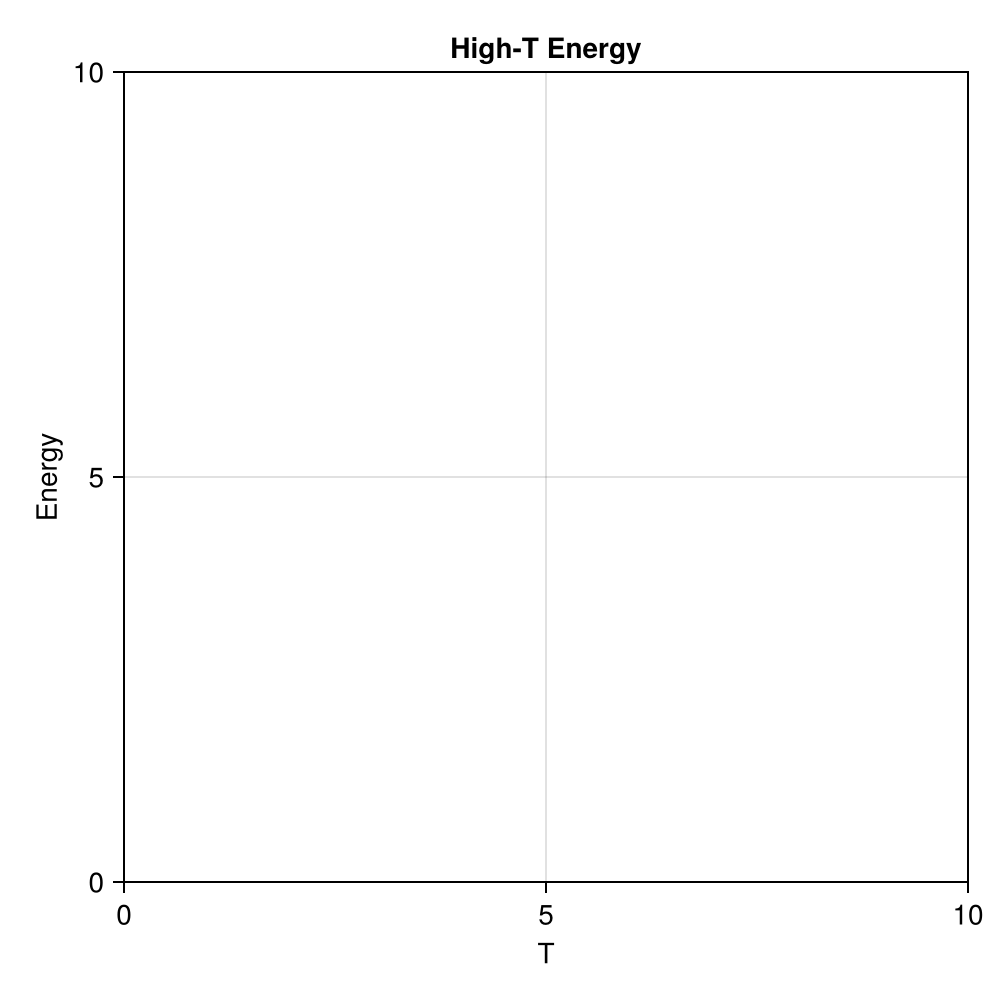

In [ ]:
fig = Figure(size=(400,400))
fig[1,1] = ax = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
fig